---
>「ある人は十銭をもって一円の十分の一と解釈する。ある人は十銭をもって一銭の十倍と解釈する。同じ言葉が人によって高くも低くもなる。」 \
>（夏目漱石）
---

# 自然言語処理（Natural Language Processing）

プログラミング言語は厳格な文法により「プロセス」を与えることで、その手順通りに処理を行わせることができる

一方で、我々が用いる言語は「自然言語」と呼ばれるが、曖昧であり、意味が明確に定義されていない多様な言語である

計算機がこのような自然言語を扱うことは従来困難であったが、DNNの発展により扱うことが可能となった

## 自然言語処理の応用

- 検索エンジン
- 機械翻訳
  - DeepLなど
- 予測変換
  - GitHubはMicrosoftが所有しており大量の優良なコードを用いて自動実装や文法だけでなく意味チェックを行うことを目指しているといわれる
- スパムフィルタ
  - ベイズ網がよく利用されていたがNLP技術の利用が進んでいる
- 音声アシスタント
  - Alexaなど
- 対話システム
  - 小説の執筆
    - AIノベリスト(https://ai-novel.com/novel.php)
  - 一般的な文章処理
    - ChatGPT, Gemini, Copilot, Claudeなど
  - 画像生成
    - Stable Diffusionなど
  - 動画生成
    - Soraなど
  - 楽曲生成
    - udioなど

### AIノベリストでちょっと遊んでみた
「そこには誰もいなかった。しかし、何か咳をする音が聞こえる。」ここまで入力して、以下自動作文させてみた

```
「誰だ？」と私は叫んだ。
咳は止まらない。
私は暗闇の中に目を凝らした。
そして闇の向こうに人影を確認すると、それが誰なのかが分かった。
「父さん」
私はそう言って一歩踏み出した。
「来るな！」と父は言った。
その声には聞き覚えがあった。
「父さんだろ？ どうしてこんなところにいるんだよ」
返事はなかった。
父はただそこに立ち尽くしていた。
私の頭の中を様々な疑問や感情が入り乱れた。どうして今になって現れたのか。この部屋には父の思い出...
```

### ChatGPTで遊んでみた
『「そこには誰もいなかった。しかし、何か咳をする音が聞こえる。」この後に続く文章を生成して小説を完成させてください。』とプロンプトで指示して以下自動作文させてみた
```
そこには誰もいなかった。しかし、何か咳をする音が聞こえる。
その音は、一瞬だけだった。けれど確かに、乾いた空気を震わせるような、かすれた喉の奥から漏れるような咳だった。私は足を止め、周囲を見渡した。荒れた床、剥がれかけた壁紙、かつては人が暮らしていた気配だけが残る、忘れられた洋館の一室——
再び、咳がした。今度は、より近くから。
「……誰か、いるんですか？」
私は声をかけた。返事はなかったが、奥の扉がわずかに揺れているのが見えた。風だろうか、それとも——
扉を押すと、鈍い音を立てて開いた。薄暗い室内には、ほとんど何もない。だが、窓辺の揺れるカーテンの向こう、微かに何かが動いた。
そこには、影があった。
人の形をしているが、輪郭が曖昧で、まるで霧の中に立つようにぼやけている。影は、こちらを向いていた。目が合った、と感じた瞬間、私の背筋を冷たいものが駆け上がった。
「ここは……もう誰も来ないと思っていた」
影が、低く、しかしはっきりと語りかけてきた。
「なぜ、あなたはここに来たのですか？」
私は答えられなかった。なぜこの館に足を踏み入れたのか、自分でもよく分かっていなかった。ただ引き寄せられるように——この場所に「呼ばれた」ような気がしていたのだ。
「あなたは……覚えていないのですね」
影が微笑んだ気がした。だがその瞬間、部屋全体が歪むような感覚が走り、私は床に膝をついた。遠くで、再び咳が聞こえた。今度は、自分自身の声のように感じられた。
記憶の底から、忘れていた何かが、静かに浮かび上がろうとしていた。
```

まずは、この章で使うライブラリを導入する
- word2vecの実習で用いる `gensim` を導入する
- 以前は `numpy` や `scipy` を古い版に固定する必要があったが、`gensim` 4.4以降は新しい版にそのまま対応しているため、固定は不要である

In [1]:
# word2vec の実習で使う gensim を導入する（版は固定しない）
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 56.2 MB/s eta 0:00:00


版を固定しないので、通常は**セッションの再起動**は不要である

実行後に再起動を促す表示が出た場合のみ**再起動し**、もう一度最初から実行するとよい

## 機械可読辞書とコーパス

NLPにおいては、大量の「我々が普段扱う言語を電子データ化した情報」が必要となる
- NLPに限らずDNNは一般的に教師データとしての大量のデータが必要であるが、特にNLPは量が必要
- 従来はこのような情報の入手が困難であった
- 現在は、SNSやWebの情報などあらゆる言語情報が電子化されており、これらを用いたデータセットを構築できるようになった

この情報セットをコーパス(Corpus)と呼び、言語の使い方を記録・蓄積した文章集合一般のことを指す
- 特に計算機が理解できる辞書として利用できる場合、機械可読辞書(Machine-Readable Dictionary)と呼ぶ


## 形態素解析(Morphological Analysis)

コーパスがあっても直接処理するのは困難である
- そのままでは単純なデータの羅列にしかならず、無加工で解析するのは困難
- そこで、自然言語のテキストデータから、対象言語の文法や単語の品詞等の情報(辞書)に基づいて意味を持つ最小単位語句(形態素:Morpheme)に分割する
  - これを「形態素解析」と呼ぶ
  - 形態素の品詞等を判別する作業であるが、品詞を問わず分割だけ行うこともしばしば行われ、この分割作業を特に「分かち書き」と呼ぶ

例えば、「じょうしがくるまでまつ」を形態素解析するとする

もし、単純な辞書(言葉としてあり得る単語群だけで構成されている)の場合、次のような分割が想定される(実際にはごく一部でありさらに大量の分類が考えられる)
- じょ うし が くる ま でま つ (序 牛が来る 間 デマ 津)
- じょ うし が くる まで まつ (序 牛が来るまで待つ)
- じょ うし が くるま で まつ (序 牛が車で待つ)
- じょ うし が くるま でま つ (序 牛が車デマ津)
- じょう し が くる まで まつ (上/穣 死が来るまで待つ)
- じょう しが くるま でま つ (上 死が車 デマ 津)
- じょうし が くる ま で ま つ (上司が来る間で間 津)
- じょうし が くる ま で まつ (上司が来る間で待つ)
- じょうし が くる ま でま つ (上司が来る間 デマ 津)
- じょうし が くる まで まつ (上司が来るまで待つ)
- じょうし が くるま で まつ (上司が車で待つ)

出来の悪い日本語変換システムの様であるが、形態素解析の難しさを説明するには十分であろう
- 機械学習で自然言語を扱う際、そのために文章を分かち書きすることすら厄介な作業であり、分かち書きのために追加で機械学習が必要というやるせなさ
- 英語は分かち書きが文法として含まれており極めて合理的に機械学習させることができる
  - 機械学習に向いている言語と向いていない言語がある
  - 日本語は向いていない、少なくとも上記の例でも英語ならば、My boss is waiting in the car.などと分かち書きされているので何も混乱なく解析できる

日本語の授業で自然言語処理を扱うのは、本当にエグイ


### MeCabを使ってみよう
MeCabライブラリを利用して分かち書きしてみよう
- MeCabのすごさはすぐにわかるので、まずはインストールして試してみよう

In [2]:
!apt install -y -q libmecab-dev mecab mecab-ipadic-utf8
!pip install -q mecab-python3

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libmecab2 mecab-ipadic mecab-jumandic mecab-jumandic-utf8 mecab-utils
The following NEW packages will be installed:
  libmecab-dev libmecab2 mecab mecab-ipadic mecab-ipadic-utf8 mecab-jumandic
  mecab-jumandic-utf8 mecab-utils
0 upgraded, 8 newly installed, 0 to remove and 2 not upgraded.
Need to get 23.5 MB of archives.
After this operation, 275 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/main amd64 libmecab2 amd64 0.996-14ubuntu4 [201 kB]
Get:2 http://archive.ubuntu.com/ubuntu noble/main amd64 libmecab-dev amd64 0.996-14ubuntu4 [311 kB]
Get:3 http://archive.ubuntu.com/ubuntu noble/main amd64 mecab-utils amd64 0.996-14ubuntu4 [4,804 B]
Get:4 http://archive.ubuntu.com/ubuntu noble/universe amd64 mecab-jumandic-utf8 all 7.0-20130310-7 [16.2 MB]
Get:5 http://archive.ubuntu.com/ubuntu noble/universe amd64 mecab-

mecabインストール時に、/usr/local/etc/mecabrcではなく/etc/mecabrcに配置され、 \

error message: [ifs] no such file or directory: /usr/local/etc/mecabrc \

というエラーになるが、これを回避するため、シンボリックリンクを貼る

In [3]:
!ln -sf /etc/mecabrc /usr/local/etc/mecabrc

コマンドライン実行可能なMeCabも入るので実際に試してみよう
- 日本語の形態素解析エンジンの中では最もよく使用されている
- これがMeCabである、いろいろ試してみるとよい

In [4]:
!echo すもももももももものうち | mecab

すもも	名詞,一般,*,*,*,*,すもも,スモモ,スモモ
も	助詞,係助詞,*,*,*,*,も,モ,モ
もも	名詞,一般,*,*,*,*,もも,モモ,モモ
も	助詞,係助詞,*,*,*,*,も,モ,モ
もも	名詞,一般,*,*,*,*,もも,モモ,モモ
の	助詞,連体化,*,*,*,*,の,ノ,ノ
うち	名詞,非自立,副詞可能,*,*,*,うち,ウチ,ウチ
EOS


## 構文解析（係り受け解析）

形態素解析の結果からわかるように、「これはあり得ない」「この可能性は極めて少ない」という分類がある

これらをどのように省くか、その手法をいくつか挙げる

まず構文解析
- 係り受け解析とも呼ばれる
- 形態素解析で得られた単語間の関係性を解析する
- 各品詞を辞書から得て、その品詞の並びが自然かどうかを見る

「じょ うし が くる ま でま つ (序 牛が来る 間 デマ 津)」は、(人名?)(一般名詞)(助詞)(動詞-連体形)(名詞)(名詞)(名詞)と最後が名詞の連続になり不自然というのがわかる

## 単語の数え上げによる文書表現と検索

形態素解析で文を単語に分けられるようになった
- 次に知りたいのは、分けた単語をどう数値にして計算機に渡すかである
- 分散表現（次節）へ進む前に、最も素朴な方法である**単語を数える**方法を押さえておく

数えるだけの方法は古典的であるが、現在も現役である
- 検索エンジンの基本であり、LLMに外部知識を与えるRAG（Retrieval-Augmented Generation、検索拡張生成）でも、質問に関係する文書を探す段階で使われる
  - RAGそのものは「M-LLM-2-Application」の章で扱う
- 学習が不要で、速く、なぜその文書が選ばれたかを単語単位で説明できる

ここでは次の順に進める
- Bag-of-Wordsとn-gram: 文書を単語の出現回数のベクトルにする
- TF-IDFとストップワード: 単語ごとに重みをつける
- コサイン類似度: ベクトルの向きで文書を探す
- BM25: TF-IDFの弱点を補った検索用の採点式
- 転置インデックス: 大量の文書から速く探す仕組み
- 日本語での検索と、検索の良さを測る指標
- 数え上げの限界

### Bag-of-Words（単語の袋）

**Bag-of-Words**（BoW）は、文書を「どの単語が何回出たか」だけで表す方法である
- コーパス全体に現れる単語を並べて語彙（vocabulary）とする
- 文書1つを、語彙の大きさ $V$ と同じ長さのベクトルにし、各要素にその単語の出現回数を入れる
- 文書が $N$ 個あれば $N \times V$ の行列になり、これを文書-単語行列と呼ぶ

<img src="https://class.west.sd.keio.ac.jp/dataai/text/bow-vectorize.png" width=700>

上の図では、文書を単語に分け、語彙の順に出現回数を並べている
- 語彙にあるがこの文書に出ない単語（`gpu`、`stock`）の要素は0になる


袋に単語を放り込んで振った状態を想像するとよい
- 何が何個入っているかはわかるが、**並んでいた順序は失われる**
- 順序を捨てるのは乱暴に見えるが、「何について書かれた文書か」は単語の顔ぶれでおおよそ決まるので、検索や文書分類には十分に役立つ

<img src="https://class.west.sd.keio.ac.jp/dataai/text/bow-word-order.png" width=600>

上の図のように、語順だけが違う2つの文は同じベクトルになる


まずは分かち書きの心配がない英語の小さなコーパスで自作する

In [5]:
# Bag-of-Words を自作する（文書-単語行列を作る）
import numpy as np

docs = [
    "gpu news gpu prices gpu market gpu supply and the gpu shortage",  # 0: gpu を連呼する記事
    "training a neural network on the gpu takes time",            # 1: 学習の話
    "the neural network has a lot of layers",                     # 2
    "the stock market news and the stock prices",                 # 3
    "training a dog takes the time and a lot of patience",        # 4
    "the dog bites a man",                                        # 5
    "a man bites the dog",                                        # 6: 5と語順だけが違う
]

def tokenize_en(text):
    # 英語は空白で区切るだけで単語になる
    return text.lower().split()

def build_vocab(token_lists):
    # 語彙: コーパスに現れる単語を辞書順に並べ、番号を振る
    words = sorted({w for tokens in token_lists for w in tokens})
    return {w: i for i, w in enumerate(words)}

def bow_matrix(token_lists, vocab):
    # 文書-単語行列（行: 文書、列: 単語、値: 出現回数）
    X = np.zeros((len(token_lists), len(vocab)))
    for d, tokens in enumerate(token_lists):
        for w in tokens:
            if w in vocab:          # 語彙にない単語は数えない
                X[d, vocab[w]] += 1
    return X

tokens_en = [tokenize_en(d) for d in docs]
vocab = build_vocab(tokens_en)
X = bow_matrix(tokens_en, vocab)

print("語彙数 V =", len(vocab), " 文書数 N =", len(docs))
print("文書0のベクトル:", {w: int(X[0, i]) for w, i in vocab.items() if X[0, i] > 0})
print("文書5と文書6のベクトルは同じか:", np.array_equal(X[5], X[6]))

語彙数 V = 24  文書数 N = 7
文書0のベクトル: {'and': 1, 'gpu': 5, 'market': 1, 'news': 1, 'prices': 1, 'shortage': 1, 'supply': 1, 'the': 1}
文書5と文書6のベクトルは同じか: True


結果から次のことがわかる
- 文書0は `gpu` が4回と数えられ、残りの単語は1回ずつである
- "dog bites man" と "man bites dog" は**まったく同じベクトル**になる
  - 犬が噛んだのか人が噛んだのかは、BoWでは区別できない
- 行列のほとんどの要素は0である
  - 語彙が数万語あっても1つの文書に出る単語はごく一部であり、このようなベクトルを**疎ベクトル**（sparse vector）と呼ぶ

### n-gramで語順を少し取り戻す

語順を完全に捨てるのが惜しければ、数える単位を広げればよい
- 連続する $n$ 個の単語をまとめて1つの単位とみなし、これを**単語n-gram**と呼ぶ
  - $n=1$ をuni-gram、$n=2$ をbi-gram、$n=3$ をtri-gramと呼ぶ
  - 文字を単位とするn-gramは、この章の後半（bi-gramマルコフモデル）で改めて扱う
- "dog bites" と "man bites" は別の単位になるので、誰が噛んだのかを区別できるようになる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/bow-ngram.png" width=600>

上の図は、同じ文から作った1-gram、2-gram、3-gramである
- 窓を1語ずつずらして切り出すので、5語の文から2-gramは4個、3-gramは3個できる


ただし、代償がある

In [6]:
# 単語 n-gram を数えると、語順の情報が一部残る
def ngrams(tokens, n):
    # 連続する n 語を空白でつないで1つの単位にする
    return [" ".join(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]

for n in [1, 2, 3]:
    grams = [ngrams(t, n) for t in tokens_en]
    vocab_n = build_vocab(grams)
    X_n = bow_matrix(grams, vocab_n)
    shared = int(np.minimum(X_n[5], X_n[6]).sum())      # 文書5と文書6に共通する単位の数
    print(f"{n}-gram: 語彙数 {len(vocab_n):2d}  0でない要素の割合 {np.mean(X_n > 0):.3f}  "
          f"文書5と文書6は同じか {np.array_equal(X_n[5], X_n[6])}（共通 {shared} 個）")

print("文書5の2-gram:", ngrams(tokens_en[5], 2))
print("文書6の2-gram:", ngrams(tokens_en[6], 2))

1-gram: 語彙数 24  0でない要素の割合 0.304  文書5と文書6は同じか True（共通 5 個）
2-gram: 語彙数 42  0でない要素の割合 0.170  文書5と文書6は同じか False（共通 2 個）
3-gram: 語彙数 43  0でない要素の割合 0.146  文書5と文書6は同じか False（共通 0 個）
文書5の2-gram: ['the dog', 'dog bites', 'bites a', 'a man']
文書6の2-gram: ['a man', 'man bites', 'bites the', 'the dog']


結果の読み方
- 2-gramにすると、文書5と文書6は別のベクトルになる
  - "the dog" と "a man" は共通であるが、"dog bites" と "man bites" が異なる
  - 3-gramでは共通の単位が1つもなくなり、今度は「同じ単語を使っている」という情報のほうが失われる
- $n$ を大きくするほど語彙数が増え、行列はさらに疎になる
  - 7文書でもこれだけ増えるので、実際のコーパスでは語彙が数百万を超える
  - 同じn-gramが複数の文書に現れることが減り、文書どうしを比べる手がかりが少なくなる
- そのため、実用では1-gramと2-gramを併用する程度にとどめることが多い
  - `TfidfVectorizer(ngram_range=(1, 2))` と指定すると、両方を数える
- 語順を本格的に扱うには、系列をそのまま読むモデル（RNNやTransformer、以降の章）が必要になる

### TF-IDF

出現回数をそのまま使うと、`a` や `the` のようにどの文書にも出る単語が大きな値を持ってしまう
- これらは文書の内容を区別する役に立たない
- そこで「その文書でよく出る」ことと「他の文書にはあまり出ない」ことの両方を満たす単語を高く評価する
- これが**TF-IDF**（Term Frequency - Inverse Document Frequency）である

単語 $t$、文書 $d$ に対して次のように定義する

$$\mathrm{tf}(t,d)=\frac{\text{文書}d\text{での}t\text{の出現回数}}{\text{文書}d\text{の総単語数}},\qquad \mathrm{idf}(t)=\log\frac{N}{\mathrm{df}(t)},\qquad \mathrm{tfidf}(t,d)=\mathrm{tf}(t,d)\cdot\mathrm{idf}(t)$$

- $\mathrm{tf}$（単語頻度）: その文書の中でどれだけ出るか
- $\mathrm{df}(t)$（文書頻度）: 単語 $t$ を含む文書の数
- $\mathrm{idf}$（逆文書頻度）: 珍しい単語ほど大きくなる
  - 全文書に出る単語は $\log(N/N)=0$ となり、重みが消える
  - 対数をとるのは、$\mathrm{df}$ が1の単語と2の単語の差を、1000と1001の差より大きく扱うためである

<img src="https://class.west.sd.keio.ac.jp/dataai/text/bow-tfidf-quadrant.png" width=550>

上の図は、$\mathrm{tf}$ と $\mathrm{idf}$ の大小の組み合わせを4つに分けたものである
- 右上の「その文書によく出て、他の文書にはあまり出ない語」だけが大きな重みを持つ


scikit-learnの `TfidfVectorizer` は、同じ考え方であるが式が少し違う
- $\mathrm{tf}$ は総単語数で割らず、出現回数そのまま
- $\mathrm{idf}(t)=\ln\dfrac{1+N}{1+\mathrm{df}(t)}+1$
  - 分子と分母に1を足すのは、全単語を含む仮想の文書を1つ加えたことに相当し、0での割り算を防ぐ（平滑化）
  - 最後の $+1$ により、全文書に出る単語も重みが0にならない
- 最後に、文書ごとのベクトルを長さ1に正規化する（L2正規化）
  - 長い文書ほど値が大きくなる影響を消すためである

両方を自作し、後者が `TfidfVectorizer` と一致することを確かめる

In [7]:
# TF-IDF を自作し、TfidfVectorizer の結果と照合する
from sklearn.feature_extraction.text import TfidfVectorizer

def tfidf_textbook(X):
    # 教科書の定義: tf = 回数 / 文書の総単語数、idf = log(N / df)
    N = X.shape[0]
    df = (X > 0).sum(axis=0)                    # 各単語を含む文書の数
    tf = X / X.sum(axis=1, keepdims=True)
    idf = np.log(N / df)
    return tf * idf, idf

def tfidf_sklearn_style(X):
    # scikit-learn の定義: tf = 回数、idf = ln((1+N)/(1+df)) + 1、最後にL2正規化
    N = X.shape[0]
    df = (X > 0).sum(axis=0)
    idf = np.log((1 + N) / (1 + df)) + 1
    W = X * idf
    W = W / np.linalg.norm(W, axis=1, keepdims=True)
    return W, idf

W_text, idf_text = tfidf_textbook(X)
W_sk, idf_sk = tfidf_sklearn_style(X)

# analyzer に自作のトークナイザを渡すと、語彙は同じ辞書順になる
vectorizer = TfidfVectorizer(analyzer=tokenize_en)
W_lib = vectorizer.fit_transform(docs).toarray()
assert list(vectorizer.get_feature_names_out()) == list(vocab)
print("自作（scikit-learn方式）と TfidfVectorizer の最大誤差:", np.abs(W_sk - W_lib).max())
assert np.allclose(W_sk, W_lib)

# idf の小さい単語（ありふれた語）と大きい単語（珍しい語）
words = list(vocab)
order = np.argsort(idf_text)
print("idf が小さい語:", [(words[i], round(float(idf_text[i]), 2)) for i in order[:4]])
print("idf が大きい語:", [(words[i], round(float(idf_text[i]), 2)) for i in order[-4:]])

# 文書3（the と stock が2回ずつ出る）で重みの大きい単語を、2つの方式で比べる
for name, W in [("教科書の式", W_text), ("scikit-learn方式", W_sk)]:
    top = np.argsort(-W[3])[:4]
    print(f"文書3の上位語（{name}）:", [(words[i], round(float(W[3, i]), 3)) for i in top])

自作（scikit-learn方式）と TfidfVectorizer の最大誤差: 1.1102230246251565e-16
idf が小さい語: [('the', 0.0), ('a', 0.34), ('dog', 0.85), ('and', 0.85)]
idf が大きい語: [('patience', 1.95), ('supply', 1.95), ('shortage', 1.95), ('stock', 1.95)]
文書3の上位語（教科書の式）: [('stock', 0.486), ('news', 0.157), ('prices', 0.157), ('market', 0.157)]
文書3の上位語（scikit-learn方式）: [('stock', 0.742), ('the', 0.311), ('news', 0.308), ('market', 0.308)]


結果の読み方
- 自作した値は `TfidfVectorizer` と誤差の範囲で一致する
  - ライブラリの中身は、数え上げ、idfの掛け算、正規化の3段階にすぎない
- idfが最も小さいのは `the` で、7文書すべてに現れるため教科書の式では0になる
  - 次に小さい `a` は5文書に現れる
  - 1文書にしか出ない `stock` や `shortage` は最大になる
- 文書3には `the` と `stock` が2回ずつ出るが、扱いは方式によって分かれる
  - 教科書の式では `the` の重みは0で、上位に現れない
  - scikit-learn方式では $+1$ があるため0にならず、2回出る `the` が `stock` に次ぐ2位に入る
  - 式の細部で順位が変わることを覚えておくとよい
- 値そのものは方式によって異なるので、異なるライブラリのTF-IDFの値を直接比べてはいけない

### ストップワード

`the` や `a` のように、どの文書にも現れて内容の区別に役立たない語を**ストップワード**（stop word）と呼ぶ
- idfで重みを下げるのではなく、数える前に取り除いてしまう方法である
- 取り除き方は2通りある
  - あらかじめ用意した一覧に載っている語を除く
  - 文書頻度を数え、一定の割合以上の文書に現れる語を除く（`TfidfVectorizer` の `max_df`）

In [8]:
# ストップワードを除くと、語彙と重みがどう変わるかを確かめる
stop_words = {"a", "the", "and", "of", "on"}

def tokenize_en_stop(text):
    # 一覧に載っている語を捨てる
    return [w for w in tokenize_en(text) if w not in stop_words]

vec_stop = TfidfVectorizer(analyzer=tokenize_en_stop)
W_stop = vec_stop.fit_transform(docs).toarray()
words_stop = list(vec_stop.get_feature_names_out())
print("語彙数:", len(vocab), "->", len(words_stop))
top = np.argsort(-W_stop[3])[:4]
print("文書3の上位語（ストップワード除去後）:", [(words_stop[i], round(float(W_stop[3, i]), 3)) for i in top])

# 一覧を使わず、文書頻度で自動的に除く（60%を超える文書に現れる語を捨てる）
vec_df = TfidfVectorizer(analyzer=tokenize_en, max_df=0.6).fit(docs)
print("max_df=0.6 で除かれた語:", sorted(set(vocab) - set(vec_df.get_feature_names_out())))

# 除きすぎの例: ストップワードだけでできた句は空になる
print("to be or not to be ->", [w for w in "to be or not to be".split() if w not in {"to", "be", "or", "not"}])

語彙数: 24 -> 19
文書3の上位語（ストップワード除去後）: [('stock', 0.812), ('market', 0.337), ('news', 0.337), ('prices', 0.337)]
max_df=0.6 で除かれた語: ['a', 'the']
to be or not to be -> []


結果の読み方
- 文書3の上位から `the` が消え、内容を表す語だけが残る
- `max_df` を使うと、一覧を用意しなくても `the` と `a` が自動的に除かれる
  - 一方で `and` や `of` は、この小さなコーパスでは出現する文書が少ないため残る
  - 文書頻度による方法は、コーパスが十分に大きいときに有効である
- ストップワードの除去は、語彙と計算量を減らせる反面、**情報を捨てる操作**でもある
  - 最後の例のように、ストップワードだけからなる句は検索できなくなる
  - 否定の `not` を除くと、文の意味が逆になっても区別できない
- idfや次に述べるBM25は、ありふれた語の重みを自動的に小さくするので、検索ではストップワードを除かずに済ませることも多い
  - 何を除くかは、課題と言語に合わせて決める前処理の設計である

### コサイン類似度による文書検索

文書がベクトルになれば、検索は「質問文のベクトルに近い文書を探す」問題になる
- 質問文（クエリ、query）も、文書と同じ語彙、同じidfでベクトルにする
- 近さは**コサイン類似度**（cosine similarity）で測る

$$\cos(\mathbf{q},\mathbf{d})=\frac{\mathbf{q}\cdot\mathbf{d}}{\|\mathbf{q}\|\,\|\mathbf{d}\|}$$

- ベクトルの長さではなく向きを比べるので、文書が長いか短いかに左右されにくい
- 共通の単語が1つもなければ内積は0、つまり類似度0となる
- L2正規化済みのベクトル同士であれば、内積がそのままコサイン類似度になる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/bow-cosine.png" width=550>

上の図は、単語が2つしかない場合の模式図である
- クエリ $\mathbf{q}$ との角度が小さい文書Aは類似度が高く、角度が大きい文書Bは低い
- 文書Aと同じ内容で長い文書A′は、矢印が長くなるだけで向きは変わらないので、類似度も変わらない

In [9]:
# TF-IDF とコサイン類似度で文書を検索する
def search_tfidf(query, top_k=3):
    # クエリを文書と同じ語彙と idf でベクトルにする
    q = bow_matrix([tokenize_en(query)], vocab)[0] * idf_sk
    if np.linalg.norm(q) == 0:
        return []                               # 語彙にある単語が1つもない
    q = q / np.linalg.norm(q)
    scores = W_sk @ q                           # 正規化済みなので内積がコサイン類似度
    return [(int(d), float(scores[d])) for d in np.argsort(-scores)[:top_k]]

for query in ["neural network", "stock prices", "dog"]:
    print(f"クエリ: {query}")
    for d, s in search_tfidf(query):
        print(f"  {s:.3f}  文書{d}: {docs[d]}")

クエリ: neural network
  0.514  文書2: the neural network has a lot of layers
  0.496  文書1: training a neural network on the gpu takes time
  0.000  文書0: gpu news gpu prices gpu market gpu supply and the gpu shortage
クエリ: stock prices
  0.767  文書3: the stock market news and the stock prices
  0.113  文書0: gpu news gpu prices gpu market gpu supply and the gpu shortage
  0.000  文書1: training a neural network on the gpu takes time
クエリ: dog
  0.463  文書6: a man bites the dog
  0.463  文書5: the dog bites a man
  0.272  文書4: training a dog takes the time and a lot of patience


クエリの単語を含む文書が上位に来ることを確認できる
- "neural network" では、2語とも含む文書2と文書1が上位に並び、どちらも含まない文書は類似度0になる
- "stock prices" では、2語とも含む文書3が、`prices` だけを含む文書0を大きく引き離す
- "dog" では、文書5と文書6が同点で並ぶ
  - BoWでは同じベクトルなので、区別できない
  - 文書4も `dog` を1回含むが、他の単語が多く、クエリとの向きがずれるので類似度は低くなる

### BM25

TF-IDFとコサイン類似度による検索には、弱点が2つある
- **同じ単語の繰り返しに弱い**
  - TFは出現回数に比例するので、ある単語を10回書いた文書は1回書いた文書の10倍の重みを持つ
  - しかし、10回出たからといって10倍関係が深いわけではない
- **クエリの単語を多く含むことを評価しにくい**
  - 1つの単語を連呼する短い文書が、クエリの単語をすべて含む普通の文書に勝ってしまうことがある

**BM25**（Best Matching 25）は、この2点を修正した検索用の採点式である
- クエリ $q$ に含まれる単語 $t$ ごとに点数を計算し、合計する

$$\mathrm{score}(q,d)=\sum_{t\in q}\mathrm{idf}(t)\cdot\frac{f(t,d)\,(k_1+1)}{f(t,d)+k_1\left(1-b+b\,\dfrac{|d|}{\mathrm{avgdl}}\right)},\qquad \mathrm{idf}(t)=\ln\left(\frac{N-\mathrm{df}(t)+0.5}{\mathrm{df}(t)+0.5}+1\right)$$

- $f(t,d)$: 文書 $d$ での単語 $t$ の出現回数
- $|d|$: 文書 $d$ の単語数、$\mathrm{avgdl}$: 全文書の平均単語数
- idfの式は実装によって少しずつ異なり、ここでは値が負にならない形を用いる

式の形は、極端な場合を代入すると理解しやすい（文書の長さが平均と同じ、つまり $|d|=\mathrm{avgdl}$ とする）
- $f=0$ なら分数は0で、その単語は点数に寄与しない
- $f=1$ なら分数は $\dfrac{k_1+1}{1+k_1}=1$ で、点数は $\mathrm{idf}(t)$ そのものになる
- $f\to\infty$ なら分数は $k_1+1$ に近づく
  - つまり、何回出ても1回出たときの $k_1+1$ 倍までしか評価しない
- この式は、文書がクエリに適合する確率を単語の出現回数から見積もる確率モデルを、計算しやすい形に近似して得られたものである
  - 導出の詳細は参考文献（Robertson and Zaragoza, 2009）に譲り、ここでは式の振る舞いを理解することを目標にする

<img src="https://class.west.sd.keio.ac.jp/dataai/text/bow-bm25-saturation.png" width=700>

上の図は、1回の出現の点数を1として、2つの文書の点数を横棒の長さで比べた模式図である
- 出現回数に比例させると、`gpu` を5回繰り返した文書0が長くなる
- BM25では `gpu` の分が上限（破線）の手前で頭打ちになり、2つの語を1回ずつ含む文書1のほうが長くなる


パラメータは2つである
- $k_1$: **TFの飽和**の速さを決める
  - $f$ を大きくしていくと分数は $k_1+1$ に近づき、それ以上は増えない
  - $k_1=0$ なら、出現回数を無視して「含むか含まないか」だけを見る
  - $k_1$ を大きくするほど飽和が遅くなり、出現回数に比例するTF-IDFに近づく
  - 1.2〜2.0がよく使われる
- $b$: **文書長の正規化**の強さを決める（0〜1）
  - 平均より長い文書では分母が大きくなり、点数が下がる
  - 長い文書は単語を多く含むので、偶然クエリの単語を含みやすいことを補正している
  - $b=0$ なら文書の長さを無視し、$b=1$ なら長さに完全に比例させて補正する
  - 0.75がよく使われる

In [10]:
# BM25 を自作する
def bm25_scores(query_tokens, token_lists, k1=1.5, b=0.75):
    # 全文書に対する BM25 の点数を返す
    N = len(token_lists)
    doc_len = np.array([len(t) for t in token_lists])
    avgdl = doc_len.mean()
    scores = np.zeros(N)
    for t in set(query_tokens):                 # クエリ内の重複は1回として扱う
        f = np.array([tokens.count(t) for tokens in token_lists])   # 各文書での出現回数
        df = (f > 0).sum()
        if df == 0:
            continue                            # どの文書にもない単語は点数に寄与しない
        idf = np.log((N - df + 0.5) / (df + 0.5) + 1)
        m = f > 0                               # その単語を含む文書だけ加点する
        scores[m] += idf * f[m] * (k1 + 1) / (f[m] + k1 * (1 - b + b * doc_len[m] / avgdl))
    return scores

def search_bm25(query, token_lists, tokenizer, top_k=3, **params):
    scores = bm25_scores(tokenizer(query), token_lists, **params)
    return [(int(d), float(scores[d])) for d in np.argsort(-scores)[:top_k] if scores[d] > 0]

# TF-IDF と BM25 で順位が入れ替わる例
query = "gpu training"
print(f"クエリ: {query}")
print("[TF-IDF + コサイン類似度]")
for d, s in search_tfidf(query):
    print(f"  {s:.3f}  文書{d}: {docs[d]}")
print("[BM25]")
for d, s in search_bm25(query, tokens_en, tokenize_en):
    print(f"  {s:.3f}  文書{d}: {docs[d]}")

クエリ: gpu training
[TF-IDF + コサイン類似度]
  0.626  文書0: gpu news gpu prices gpu market gpu supply and the gpu shortage
  0.496  文書1: training a neural network on the gpu takes time
  0.225  文書4: training a dog takes the time and a lot of patience
[BM25]
  2.239  文書1: training a neural network on the gpu takes time
  2.076  文書0: gpu news gpu prices gpu market gpu supply and the gpu shortage
  1.014  文書4: training a dog takes the time and a lot of patience


順位が入れ替わったことを確認する
- TF-IDFでは、`gpu` を5回繰り返す文書0が1位になる
  - 文書0のベクトルはほぼ `gpu` の方向を向いており、クエリとの角度が小さい
  - `training` を含まないにもかかわらず、である
- BM25では、`gpu` と `training` の両方を含む文書1が1位になる
  - `gpu` の5回分の点数は飽和して頭打ちになり、2つ目の単語を含むことによる加点がそれを上回る
- クエリの単語をより多く含む文書を上位にする、という検索の直感に合うのはBM25である

次に、$k_1$ と $b$ の効果を図で確かめる

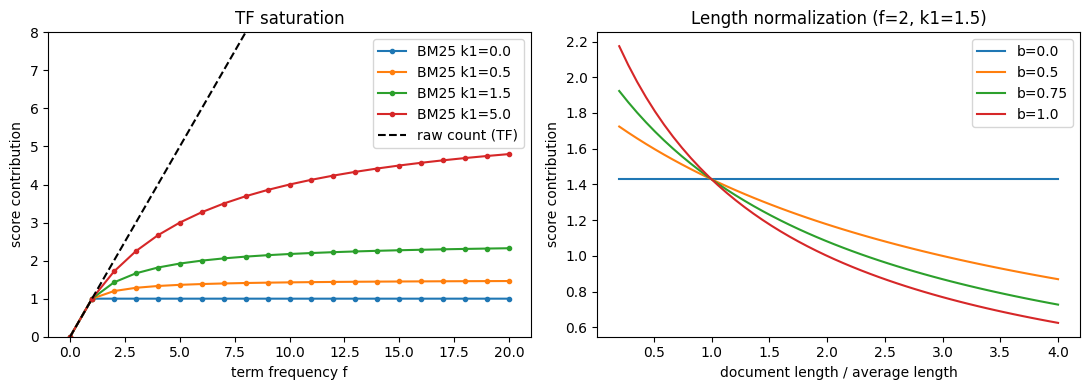

k1=1.5  b=0.75 順位: [1, 0, 4]  点数: [2.24, 2.08, 1.01]
k1=0.0  b=0.75 順位: [1, 0, 4]  点数: [2.33, 1.16, 1.16]
k1=50.0 b=0.75 順位: [0, 1, 4]  点数: [4.13, 2.19, 0.94]
k1=1.5  b=0.0  順位: [1, 0, 4]  点数: [2.33, 2.24, 1.16]


In [11]:
# k1 による TF の飽和と、b による文書長の補正を図示する
import matplotlib.pyplot as plt

f = np.arange(0, 21)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 左: 出現回数 f に対する点数（文書長は平均と同じ、idf は 1 とする）
for k1 in [0.0, 0.5, 1.5, 5.0]:
    axes[0].plot(f, f * (k1 + 1) / (f + k1 + 1e-12), marker="o", ms=3, label=f"BM25 k1={k1}")
axes[0].plot(f, f, "k--", label="raw count (TF)")
axes[0].set_ylim(0, 8)
axes[0].set_xlabel("term frequency f")
axes[0].set_ylabel("score contribution")
axes[0].set_title("TF saturation")
axes[0].legend()

# 右: 文書長に対する点数（出現回数 2、k1=1.5 に固定）
ratio = np.linspace(0.2, 4, 50)                 # 文書長 / 平均文書長
for b in [0.0, 0.5, 0.75, 1.0]:
    axes[1].plot(ratio, 2 * (1.5 + 1) / (2 + 1.5 * (1 - b + b * ratio)), label=f"b={b}")
axes[1].set_xlabel("document length / average length")
axes[1].set_ylabel("score contribution")
axes[1].set_title("Length normalization (f=2, k1=1.5)")
axes[1].legend()
plt.tight_layout()
plt.show()

# パラメータを変えると、先ほどのクエリの順位がどう変わるか
for k1, b in [(1.5, 0.75), (0.0, 0.75), (50.0, 0.75), (1.5, 0.0)]:
    result = search_bm25("gpu training", tokens_en, tokenize_en, k1=k1, b=b)
    print(f"k1={k1:<4} b={b:<4} 順位: {[d for d, _ in result]}  点数: {[round(s, 2) for _, s in result]}")

図と数値の読み方
- 左の図: 出現回数をそのまま使う場合（破線）は直線的に増え続けるが、BM25は $k_1+1$ で頭打ちになる
  - $k_1=0$ では出現回数によらず一定となり、単語を含むかどうかだけを見る
  - 最初の1回が最も大きく効き、2回目以降の増分は小さくなっていく
- 右の図: $b$ が大きいほど、長い文書の点数が強く下げられる
  - $b=0$ では水平になり、文書の長さは点数に影響しない
- $k_1=0$ にすると、`gpu` を5回含む文書0と、`training` を1回含むだけの文書4が同点になる
  - 出現回数をまったく見ていないことがわかる
- $k_1$ を極端に大きくすると飽和しなくなり、`gpu` を連呼する文書0が再び1位になる
  - TF-IDFで起きていたことを、BM25の中で再現したことになる
- $k_1$ と $b$ に万能の値はなく、対象とする文書の性質（長さのばらつき、繰り返しの多さ）に合わせて調整する

### 転置インデックス: 検索はなぜ速いのか

ここまでの実装は、クエリが来るたびに**全文書**を調べている
- 文書が7個なら問題ないが、数百万個になると1回の検索に時間がかかりすぎる
- しかし、クエリの単語を1つも含まない文書の点数は必ず0であり、調べる必要がない

そこで、あらかじめ「単語 → その単語を含む文書の一覧」という表を作っておく
- これを**転置インデックス**（inverted index）と呼ぶ
  - 文書 → 単語、という文書-単語行列の向きを逆にしたものである
  - 本の巻末の索引と同じ仕組みである
- 一覧の各要素（文書番号と出現回数の組）を**ポスティング**（posting）と呼ぶ
- 検索時は、クエリの単語の一覧だけをたどり、そこに現れる文書だけを採点する

<img src="https://class.west.sd.keio.ac.jp/dataai/text/bow-inverted-index.png" width=750>

上の図の左が文書ごとの数え上げ、右が転置インデックスである
- クエリ "gpu training" では、`gpu` と `training` の行だけを読めばよく、`dog` の行やそこにしか現れない文書には触れない


BoWやBM25でこれが可能なのは、ベクトルが疎だからである

In [12]:
# 転置インデックスを作り、クエリの単語を含む文書だけを採点する
from collections import Counter, defaultdict
import time

def build_index(token_lists):
    # 単語 -> {文書番号: 出現回数} の辞書を作る
    index = defaultdict(dict)
    for d, tokens in enumerate(token_lists):
        for t, c in Counter(tokens).items():
            index[t][d] = c
    doc_len = np.array([len(tokens) for tokens in token_lists])
    return index, doc_len

def bm25_index(query_tokens, index, doc_len, k1=1.5, b=0.75):
    # 式は bm25_scores と同じで、たどる文書だけが違う
    N, avgdl = len(doc_len), doc_len.mean()
    scores = {}
    for t in set(query_tokens):
        postings = index.get(t, {})
        df = len(postings)
        if df == 0:
            continue
        idf = np.log((N - df + 0.5) / (df + 0.5) + 1)
        for d, f in postings.items():
            scores[d] = scores.get(d, 0.0) + idf * f * (k1 + 1) / (f + k1 * (1 - b + b * doc_len[d] / avgdl))
    return scores

# 小さなコーパスで中身を見て、全文書を調べる実装と点数が一致することを確かめる
index_en, len_en = build_index(tokens_en)
print("gpu      ->", index_en["gpu"])
print("training ->", index_en["training"])
s_all = bm25_scores(tokenize_en("gpu training"), tokens_en)
s_idx = bm25_index(tokenize_en("gpu training"), index_en, len_en)
assert len(s_idx) == (s_all > 0).sum() and all(np.isclose(s_all[d], s) for d, s in s_idx.items())
print("採点した文書:", sorted(s_idx), "/ 全", len(docs), "文書")

# 人工的な大きなコーパスで速度を比べる（単語の出現頻度は順位に反比例させる）
rng = np.random.default_rng(0)
V_big, N_big = 20000, 20000
p = 1 / np.arange(1, V_big + 1)
lengths = rng.integers(20, 80, size=N_big)
ids = rng.choice(V_big, size=lengths.sum(), p=p / p.sum())
big_tokens = [[f"w{i}" for i in chunk] for chunk in np.split(ids, np.cumsum(lengths)[:-1])]

t0 = time.perf_counter()
index_big, len_big = build_index(big_tokens)
t_build = time.perf_counter() - t0

query_tokens = ["w300", "w2000", "w9000"]
t0 = time.perf_counter()
s_all = bm25_scores(query_tokens, big_tokens)
t_all = time.perf_counter() - t0
t0 = time.perf_counter()
s_idx = bm25_index(query_tokens, index_big, len_big)
t_idx = time.perf_counter() - t0

assert int(np.argmax(s_all)) == max(s_idx, key=s_idx.get)
print(f"\n文書数 {N_big}、インデックスの作成 {t_build:.2f} 秒（最初に1回だけ）")
print(f"全文書を調べる検索    : {t_all * 1000:8.2f} ms")
print(f"転置インデックスの検索: {t_idx * 1000:8.2f} ms（採点した文書 {len(s_idx)} 個）")

gpu      -> {0: 5, 1: 1}
training -> {1: 1, 4: 1}
採点した文書: [0, 1, 4] / 全 7 文書

文書数 20000、インデックスの作成 0.75 秒（最初に1回だけ）
全文書を調べる検索    :    67.75 ms
転置インデックスの検索:     1.84 ms（採点した文書 408 個）


結果の読み方
- 転置インデックスの中身は、単語ごとの「文書番号: 出現回数」の辞書である
  - "gpu training" では、`gpu` と `training` の一覧に現れる3文書だけを採点すればよい
  - 点数は全文書を調べる実装と一致する
- 大きなコーパスでは、採点する文書が全体のごく一部になり、検索時間が桁違いに短くなる
  - 実行時間は環境によって変わるが、採点した文書の数は変わらない
  - インデックスの作成には時間がかかるが、文書を登録するときに1回行えばよい
- 珍しい単語ほど一覧が短く、検索が速い
  - 逆に `the` のような語は一覧がほぼ全文書になるので、ストップワードを除くことは速度の面でも意味がある
- 全文検索エンジン（Apache Lucene、それを用いたElasticsearchなど）は、この仕組みを圧縮や並べ替えで磨き上げたものである
- 次節の分散表現のような密ベクトルは、ほぼすべての要素が0でないため、この方法は使えない
  - 密ベクトル検索を大規模に行うには、近似最近傍探索（Approximate Nearest Neighbor search）という別の種類の索引が必要になる

### 日本語で検索する

ここまで英語を使ってきたのは、空白で区切れば単語になるからである
- 日本語には単語の区切りがないので、同じ `split()` では文全体が1つの「単語」になってしまう
- したがって、数え上げの前に**分かち書きが必須**となる
  - 先ほど導入したMeCabを、今度はPythonから呼び出す
  - `-Owakati` を指定すると、品詞などを省き、空白で区切った分かち書きだけを出力する
  - `-r` は設定ファイル（mecabrc）の場所の指定である
    - 「MeCabを使ってみよう」で述べたとおり、`apt` で入れた設定ファイルは `/etc/mecabrc` にあるので、これを明示する

分かち書きさえできれば、あとは英語とまったく同じである
- `bm25_scores` はトークンのリストを受け取るように作ったので、そのまま使える

In [13]:
# MeCab で分かち書きして、日本語のコーパスを BM25 で検索する
import os
import MeCab

# apt で導入した設定ファイルがあれば明示する（無い環境では MeCab の既定の設定を使う）
MECAB_RC = "-r /etc/mecabrc" if os.path.exists("/etc/mecabrc") else ""
tagger = MeCab.Tagger(f"{MECAB_RC} -Owakati")

def tokenize_ja(text):
    # MeCab の分かち書き出力（空白区切り）をリストにする
    return tagger.parse(text).split()

docs_ja = [
    "機械学習ではGPUを使ってニューラルネットワークを学習する",
    "形態素解析は日本語の文を単語に分割する処理である",
    "検索エンジンは質問に関係する文書を順位をつけて返す",
    "コンピュータの性能が上がりニューラルネットワークの学習が速くなった",
    "猫は一日の大半を寝て過ごす動物である",
    "日本語の文書を検索するにはまず形態素解析で単語に分ける",
    "パソコンの電源が入らないときはケーブルを確認する",
]

print("split() の結果:", docs_ja[1].split())
print("MeCab の結果  :", tokenize_ja(docs_ja[1]))

tokens_ja = [tokenize_ja(d) for d in docs_ja]
for query in ["日本語の検索", "ニューラルネットワークの学習"]:
    print(f"\nクエリ: {query} -> {tokenize_ja(query)}")
    for d, s in search_bm25(query, tokens_ja, tokenize_ja):
        print(f"  {s:.3f}  文書{d}: {docs_ja[d]}")

# TfidfVectorizer も、analyzer に分かち書きの関数を渡せば日本語を扱える
W_ja = TfidfVectorizer(analyzer=tokenize_ja).fit_transform(docs_ja)
print("\n日本語の文書-単語行列の形:", W_ja.shape)

split() の結果: ['形態素解析は日本語の文を単語に分割する処理である']
MeCab の結果  : ['形態素', '解析', 'は', '日本語', 'の', '文', 'を', '単語', 'に', '分割', 'する', '処理', 'で', 'ある']

クエリ: 日本語の検索 -> ['日本語', 'の', '検索']
  2.540  文書5: 日本語の文書を検索するにはまず形態素解析で単語に分ける
  1.494  文書1: 形態素解析は日本語の文を単語に分割する処理である
  1.130  文書2: 検索エンジンは質問に関係する文書を順位をつけて返す

クエリ: ニューラルネットワークの学習 -> ['ニューラルネットワーク', 'の', '学習']
  2.972  文書3: コンピュータの性能が上がりニューラルネットワークの学習が速くなった
  2.920  文書0: 機械学習ではGPUを使ってニューラルネットワークを学習する
  0.390  文書6: パソコンの電源が入らないときはケーブルを確認する

日本語の文書-単語行列の形: (7, 51)


結果の読み方
- `split()` では文全体が1要素になり、単語として数えられない
  - このままBoWを作ると、文書ごとに異なる巨大な「単語」が1つずつあるだけになり、どのクエリとも一致しない
- MeCabで分けた後は、英語と同じ関数で検索できる
- 「日本語の検索」では、「日本語」と「検索」の両方を含む文書5が1位になる
- 助詞の「の」もクエリの単語として数えられている
  - 「ニューラルネットワークの学習」の3位に、内容の無関係な文書6が入るのは、「の」が一致したためである
  - 多くの文書に出るのでidfが小さく、点数は低いが、0ではない
  - 次に、品詞を見てこうした語を除く
- 検索の品質は分かち書きの品質に左右される
  - 辞書にない新語や専門用語が細かく分割されると、意図しない文書が当たる

### 品詞で単語を選ぶ

日本語では、ストップワードの一覧を作る代わりに、形態素解析が返す**品詞**を使って単語を選べる
- 助詞（の、を、が）や助動詞（です、た）は、ほぼすべての文に現れ、内容を表さない
- 名詞、動詞、形容詞だけを残せば、内容を表す語（内容語）が残る

MeCabは品詞と一緒に**原形**（活用していない形）も返す
- 「使って」の「使っ」と「使う」は、そのままでは別の単語として数えられる
- 原形にそろえれば、活用が違っても同じ単語として一致する

<img src="https://class.west.sd.keio.ac.jp/dataai/text/bow-japanese-pipeline.png" width=750>

上の図は、日本語の文を数え上げるまでの流れである
- 形態素解析で分かち書きした後、品詞で選んで原形にそろえる段階（図の橙色）をこれから加える

In [14]:
# MeCab の品詞と原形を使って、内容語だけを取り出す
tagger_pos = MeCab.Tagger(MECAB_RC)             # 出力形式を指定しないと、品詞などの情報が付く
print(tagger_pos.parse("GPUを使って学習する"))

basic_verbs = {"する", "なる", "ある", "いる"}  # どの文にも現れる動詞は、品詞で選んだ後に一覧で除く

def tokenize_ja_content(text, keep=("名詞", "動詞", "形容詞")):
    tokens = []
    for line in tagger_pos.parse(text).splitlines():
        if "\t" not in line:
            continue                            # 文末の EOS 行を飛ばす
        surface, feature = line.split("\t", 1)
        f = feature.split(",")                  # f[0]: 品詞、f[6]: 原形
        base = f[6] if len(f) > 6 and f[6] != "*" else surface
        if f[0] in keep and base not in basic_verbs:
            tokens.append(base)
    return tokens

print("分かち書きのみ:", tokenize_ja(docs_ja[0]))
print("内容語の原形  :", tokenize_ja_content(docs_ja[0]))

tokens_ja_content = [tokenize_ja_content(d) for d in docs_ja]
for query in ["ニューラルネットワークの学習", "GPUを使う"]:
    print(f"\nクエリ: {query}")
    print("  分かち書きのみ:", [(d, round(s, 2)) for d, s in search_bm25(query, tokens_ja, tokenize_ja)])
    print("  内容語の原形  :", [(d, round(s, 2)) for d, s in search_bm25(query, tokens_ja_content, tokenize_ja_content)])

GPU	名詞,一般,*,*,*,*,*
を	助詞,格助詞,一般,*,*,*,を,ヲ,ヲ
使っ	動詞,自立,*,*,五段・ワ行促音便,連用タ接続,使う,ツカッ,ツカッ
て	助詞,接続助詞,*,*,*,*,て,テ,テ
学習	名詞,サ変接続,*,*,*,*,学習,ガクシュウ,ガクシュー
する	動詞,自立,*,*,サ変・スル,基本形,する,スル,スル
EOS

分かち書きのみ: ['機械', '学習', 'で', 'は', 'GPU', 'を', '使っ', 'て', 'ニューラルネットワーク', 'を', '学習', 'する']
内容語の原形  : ['機械', '学習', 'GPU', '使う', 'ニューラルネットワーク', '学習']

クエリ: ニューラルネットワークの学習
  分かち書きのみ: [(3, 2.97), (0, 2.92), (6, 0.39)]
  内容語の原形  : [(0, 2.94), (3, 2.44)]

クエリ: GPUを使う
  分かち書きのみ: [(0, 2.05), (2, 0.29), (6, 0.22)]
  内容語の原形  : [(0, 3.52)]


結果の読み方
- MeCabの出力は「文中に現れた形（表層形）、タブ、品詞などの情報」の形で、情報はカンマで区切られている
  - 先頭が品詞、7番目が原形である（この章で導入したIPA辞書の場合であり、辞書によって並びが異なる）
- 「ニューラルネットワークの学習」では、助詞「の」だけで当たっていた文書6が結果から消える
- 「GPUを使う」では、分かち書きのみの場合に「使う」が文書0の「使っ」と一致せず、助詞「を」で当たった無関係な文書が並ぶ
  - 原形にそろえると「使う」も一致するようになり、文書0だけが残る
- 「する」「なる」のような動詞は品詞では除けないので、短い一覧を併用している
  - 辞書に原形が登録されていない語（`GPU` など）は、表層形をそのまま使う
- このように、英語でのストップワード除去と語形の統一に当たる処理を、日本語では形態素解析の結果を使って行う

### 検索の良さを測る

ここまでは、結果を目で見て「良さそうだ」と判断してきた
- トークナイザやパラメータを変えたときに良くなったのか悪くなったのかを判断するには、数値が必要である
- そのために、クエリごとに「見つかるべき文書」（**正解**）を人が決めておき、検索結果と照らし合わせる

よく使う指標を3つ挙げる
- **適合率**（precision）: 返した結果のうち、正解だった割合
  - 上位 $k$ 件で測るとき Precision@k と書く
  - 無関係な文書をどれだけ混ぜずに済んだかを表す
- **再現率**（recall）: 正解のうち、返した結果に含まれていた割合
  - 上位 $k$ 件で測るとき Recall@k と書く
  - 見つけるべき文書をどれだけ取りこぼさなかったかを表す
- **MRR**（Mean Reciprocal Rank、平均逆順位）: 最初の正解が何位に現れたかを見る

$$\mathrm{Precision@}k=\frac{\text{上位}k\text{件に含まれる正解の数}}{k},\qquad \mathrm{Recall@}k=\frac{\text{上位}k\text{件に含まれる正解の数}}{\text{正解の総数}},\qquad \mathrm{MRR}=\frac{1}{|Q|}\sum_{q\in Q}\frac{1}{\mathrm{rank}_q}$$

- $Q$ はクエリの集合、$\mathrm{rank}_q$ はクエリ $q$ で最初の正解が現れた順位である
  - 1位なら1、2位なら0.5、3位なら0.33となり、正解が見つからなければ0とする

<img src="https://class.west.sd.keio.ac.jp/dataai/text/bow-precision-recall.png" width=700>

上の図は、正解が2個あるクエリについて、上位3件の結果から3つの値を求めた例である
- クエリ1は正解を2個とも上位に返したので、どの値も高い
- クエリ2は正解を1個しか返せず、それも2位なので、どの値も下がる
- MRRは、この逆順位をすべてのクエリで平均したものである

- 適合率と再現率は一方を上げると他方が下がりやすい
  - 返す件数を増やせば再現率は上がるが、無関係な文書も増えて適合率は下がる
- RAGでは上位の数件だけをLLMに渡すので、上位に正解が入るかを見るMRRやRecall@kが重視される（「M-LLM-2-Application」の章でもMRRを用いる）

クエリは2種類用意する
- `same`: 文書と同じ単語を使ったクエリ
- `para`: 同じ内容を別の言葉で言い換えたクエリ

In [15]:
# 正解を付けたクエリで、適合率、再現率、MRR を計算する
# 上位3件に入る難しさを上げるため、紛らわしい文書を加えて15文書にする（文書7〜14）
docs_eval = docs_ja + [
    "犬は散歩が好きな動物である",
    "GPUの価格が上がり品薄が続いている",
    "検索エンジンの広告は質問の単語に合わせて表示される",
    "英語の文は空白で単語に分かれている",
    "電源ケーブルは束ねたまま使わない",
    "学習の速度を上げるにはバッチサイズを大きくする",
    "図書館では本を著者の名前の順に並べる",
    "日本語の入力にはかな漢字変換を使う",
]

eval_queries = [    # （種類, クエリ, 正解の文書番号の集合）
    ("same", "形態素解析で単語に分ける", {1, 5}),
    ("same", "ニューラルネットワークの学習", {0, 3}),
    ("same", "文書を検索する", {2, 5}),
    ("same", "猫", {4}),
    ("same", "GPUの価格", {8}),
    ("same", "電源が入らない", {6}),
    ("para", "計算機が高速になった", {3}),
    ("para", "PCが起動しない", {6}),
    ("para", "ネコはよく眠る", {4}),
    ("para", "文章を語に区切る", {1, 5}),
    ("para", "グラフィックボードが値上がりした", {8}),
    ("para", "イヌは外を歩くのを好む", {7}),
]

def evaluate(tokenizer, k=3, verbose=False, **params):
    # 種類ごとに Precision@k、Recall@k、MRR の平均を求める
    token_lists = [tokenizer(d) for d in docs_eval]
    rows = {}
    for kind, query, relevant in eval_queries:
        ranked = [d for d, _ in search_bm25(query, token_lists, tokenizer, top_k=len(docs_eval), **params)]
        hit = len(set(ranked[:k]) & relevant)
        rr = next((1 / r for r, d in enumerate(ranked, start=1) if d in relevant), 0.0)
        rows.setdefault(kind, []).append((hit / k, hit / len(relevant), rr))
        if verbose:
            print(f"  {kind:<5} {query}: 上位{k}件 {ranked[:k]}  正解 {sorted(relevant)}")
    return {kind: np.mean(v, axis=0) for kind, v in rows.items()}

def report(name, result):
    for kind, (p, r, mrr) in result.items():
        print(f"{name:<12} {kind:<5} Precision@3 {p:.3f}  Recall@3 {r:.3f}  MRR {mrr:.3f}")

report("分かち書きのみ", evaluate(tokenize_ja))
report("内容語の原形", evaluate(tokenize_ja_content, verbose=True))

分かち書きのみ      same  Precision@3 0.500  Recall@3 1.000  MRR 1.000
分かち書きのみ      para  Precision@3 0.222  Recall@3 0.583  MRR 0.502
  same  形態素解析で単語に分ける: 上位3件 [5, 1, 10]  正解 [1, 5]
  same  ニューラルネットワークの学習: 上位3件 [0, 3, 12]  正解 [0, 3]
  same  文書を検索する: 上位3件 [5, 2, 9]  正解 [2, 5]
  same  猫: 上位3件 [4]  正解 [4]
  same  GPUの価格: 上位3件 [8, 0]  正解 [8]
  same  電源が入らない: 上位3件 [6, 11]  正解 [6]
  para  計算機が高速になった: 上位3件 []  正解 [3]
  para  PCが起動しない: 上位3件 []  正解 [6]
  para  ネコはよく眠る: 上位3件 []  正解 [4]
  para  文章を語に区切る: 上位3件 []  正解 [1, 5]
  para  グラフィックボードが値上がりした: 上位3件 []  正解 [8]
  para  イヌは外を歩くのを好む: 上位3件 []  正解 [7]
内容語の原形       same  Precision@3 0.500  Recall@3 1.000  MRR 1.000
内容語の原形       para  Precision@3 0.000  Recall@3 0.000  MRR 0.000


結果の読み方
- `same` のクエリでは、どちらのトークナイザでも正解がすべて上位3件に入り、Recall@3とMRRが1になる
  - Precision@3が0.5にとどまるのは検索が悪いからではなく、正解が1個か2個しかないクエリで3件を数えているためである
  - この正解の付け方では0.5が上限であり、$k$ と指標は正解の数を考えて選ぶ必要がある
- `para` のクエリでは、成績が大きく下がる
  - 内容語だけにすると、6個のクエリすべてで結果が空になり、どの指標も0になる
  - 分かち書きのみの場合に0でないのは、「が」「は」などの助詞の一致で偶然に正解が拾われたためであり、内容で当てたわけではない
  - 指標の値だけを見ると分かち書きのみのほうが良く見えるが、中身を見れば偶然である
  - 平均の数値だけでなく、個々のクエリの結果も確認する習慣をつけるとよい
- 数値にすることで、「同じ言葉なら見つかるが、言い換えると見つからない」という性質がはっきり見える
- 12個のクエリでは、1つの当たり外れで値が大きく動く
  - 実際の評価では、数十から数百のクエリを用意する

### 数え上げの限界

単語の数え上げは、**文字列として同じ単語**が出ることに頼っている
- 表記が違えば別の単語になる
- 意味が同じでも、言い方が違えば一致しない

実際に確かめる

In [16]:
# 表記揺れと同義語では一致しないことを確かめる
for query in ["コンピュータ", "コンピューター", "計算機", "PC"]:
    result = search_bm25(query, tokens_ja, tokenize_ja)
    hit = [f"文書{d}（{s:.2f}）" for d, s in result] if result else "該当なし"
    print(f"クエリ: {query:<8} -> {hit}")

クエリ: コンピュータ   -> ['文書3（1.74）']
クエリ: コンピューター  -> 該当なし
クエリ: 計算機      -> 該当なし
クエリ: PC       -> 該当なし


「コンピュータ」で見つかる文書3が、他の言い方ではまったく見つからない
- 「コンピューター」は長音の有無だけの違い（**表記揺れ**）であるが、別の単語として扱われる
- 「計算機」「PC」「パソコン」は**同義語**や関連語であるが、BoWのベクトルでは互いに直交しており、類似度は0である
  - 「パソコン」を含む文書6も、「コンピュータ」や「PC」では見つからない
- 先ほどの評価で `para` のクエリの成績が悪かったのは、このためである

表記揺れには、単語の代わりに**文字n-gram**を数える方法がある程度効く
- 文を2文字ずつの組（文字bi-gram）に分ければ、形態素解析も辞書も要らない
- 「コンピュータ」と「コンピューター」は、多くの文字bi-gramを共有する

In [17]:
# 文字 bi-gram で分割し、表記揺れと同義語への効き方を確かめる
def tokenize_char2(text):
    # 隣り合う2文字の組に分ける
    return [text[i:i + 2] for i in range(len(text) - 1)] or [text]

print(tokenize_char2("コンピューター"))
tokens_char2 = [tokenize_char2(d) for d in docs_ja]
for query in ["コンピュータ", "コンピューター", "計算機", "PC"]:
    result = search_bm25(query, tokens_char2, tokenize_char2)
    hit = [f"文書{d}（{s:.2f}）" for d, s in result] if result else "該当なし"
    print(f"クエリ: {query:<8} -> {hit}")

# 文字 bi-gram の副作用: 単語の境界をまたいだ一致が起きる
print("\n「京都」は「東京都」の文字bi-gramに含まれるか:", "京都" in tokenize_char2("東京都"))
print("MeCab での「東京都」:", tokenize_ja("東京都"))

report("文字bi-gram", evaluate(tokenize_char2))

['コン', 'ンピ', 'ピュ', 'ュー', 'ータ', 'ター']
クエリ: コンピュータ   -> ['文書3（6.98）', '文書6（1.20）', '文書0（1.10）']
クエリ: コンピューター  -> ['文書3（6.98）', '文書6（1.20）', '文書0（1.10）']
クエリ: 計算機      -> 該当なし
クエリ: PC       -> 該当なし

「京都」は「東京都」の文字bi-gramに含まれるか: True
MeCab での「東京都」: ['東京', '都']
文字bi-gram    same  Precision@3 0.444  Recall@3 0.833  MRR 0.833
文字bi-gram    para  Precision@3 0.222  Recall@3 0.583  MRR 0.500


結果の読み方
- 「コンピューター」で文書3が見つかるようになる
  - 「コン」「ンピ」「ピュ」「ュー」「ータ」が共通するためである
- 一方、「計算機」と「PC」は相変わらず見つからない
  - 文字が違う以上、どう区切っても一致しない
- 文字bi-gramには副作用もある
  - 「コンピュータ」で、無関係な文書6と文書0も低い点数で当たるようになった
    - 「パソコン」の「コン」、「ニューラル」の「ュー」が一致したためである
  - 「東京都」が「京都」に当たるように、単語の境界を無視した一致が起きる
  - 「猫」のような1文字の語は2文字の組にならず、探せない
    - `same` のクエリの成績が形態素解析より下がったのは、このためである
  - 2文字の組の種類は単語の種類より多くなり、インデックスが大きくなる
- `para` のクエリの数値は内容語の場合より高いが、当たり方を調べると「ない」「なっ」のような内容と関係の薄い文字の並びの一致が多い
  - 言い換えに強くなったわけではない
- 形態素解析と文字n-gramは一長一短であり、検索エンジンでは両方のインデックスを持つこともある
  - 「M-LLM-2-Application」の章のBM25は、導入を簡単にするため文字bi-gramを用いている

### 分散表現へ

表記揺れは、文字n-gramや正規化（全角と半角の統一、長音の統一など）である程度は対処できる

しかし同義語は、辞書を人手で整備するしかなく、きりがない
- 単語を語彙の番号で表す限り、「猫」と「犬」の距離も、「猫」と「電源」の距離も同じである
  - 次節のOne-hotベクトル表現と同じ問題である
- そこで、**意味の近い単語が近いベクトルになる**ように、単語の表現そのものをデータから学習させる
- これが次節の**分散表現**であり、word2vecである
- 分散表現は要素のほとんどが0でない数百次元程度のベクトルで、BoWの疎ベクトルに対して**密ベクトル**（dense vector）と呼ぶ
  - 文や文書を密ベクトルにして近いものを探す方法を密ベクトル検索と呼び、RAGで広く使われる（「M-LLM-2-Application」の章を参照）

<img src="https://class.west.sd.keio.ac.jp/dataai/text/bow-sparse-vs-dense.png" width=700>

上の図の左が数え上げによる表現、右が分散表現である
- 左では単語ごとに別の軸を使うので、どの2語も直交する
- 右では「コンピュータ」「計算機」「PC」が近くに集まり、「猫」「犬」とは離れる

- ただし、BM25が不要になるわけではない
  - 型番や固有名詞のように、文字列として一致することが重要な検索ではBM25が強い
  - そのため、両者の結果を組み合わせるハイブリッド検索もよく使われる

## 分散表現
単語そのものを数値(ベクトル)として表現する手法で、単に番号を与えるだけでなく、単語間の関連性や類似度をベクトルの中に表現している
- 一般に200要素程度のベクトルとして表現される
- 具体例としてword2vecなどがある
- 後述するが、ベクトルの足し算や引き算などで、関連する単語を導くことができる
  - 例: 王 - 男 + 女 = 女王

# word2vec

## word2vecとは？

単語のEmbeddingは重要だが、ランダムなIDを与えるのはまずいのではないか？
- そのように感じるのはもっともである
- では意味が近い言葉に近いIDを与えることなどできるのだろうか？

word2vecはそれを可能とする、初歩的な一つの方法である

## どのようなモデルなのか？

word2vecはSkip-Gramと呼ばれるNNモデルを利用する
- Skip-Gram は２層のニューラルネットワークであり隠れ層は一つのみ
- 隣接する層のユニットは全結合している

Skip-Gram のアーキテクチャは図に示す通り
- ニューラルネットワークはあるタスクで学習させる
  - 例えば入力となる言葉に対して近い場所にある言葉を教師データとして与え、相関を学習させる
- 実際には学習したタスクに対してニューラルネットワークを使わない
- 目的は潜在空間表現を使うことにある
  - 潜在空間ベクトルを単語ベクトル(図の$W_{V\times N}$)と呼び、これを単語のIDとすることを目的とする


<img src="http://class.west.sd.keio.ac.jp/dataai/text/w2v1.png" width=400>

### Skip-Gram が行うタスク

Skip-gramでは、ある単語を入力した時、その周辺にどのような単語が現れやすいかを予測するモデルを構築する
- 学習は教師あり学習で行い、入力としてある単語を、出力としてその周辺語を与える
  - これらの単語は訓練データ内に現れる単語
- これらの単語を与え、ネットワークにある単語に対するその周辺語の確率を学習させる

例えば、"I want to eat an apple everyday."という文章があった場合、eatに注目した場合の周辺単語は、周辺語として何単語まで考えるのかという指標であるウィンドウサイズ$C$を定めると次の単語が該当する

<img src="http://class.west.sd.keio.ac.jp/dataai/text/w2v2.png" width=400>

周辺語の数を1つとした時の入出力のイメージは次の通り

<img src="http://class.west.sd.keio.ac.jp/dataai/text/w2v3.png" width=400>

このネットワークの学習が進めば、近しい場所にあった単語ほど、高い値が出力されるようになるであろう



### One-hotベクトル表現

では、さらに具体的に入力と出力にはどのように単語を与えるべきか？
- 単語はもとより可変長
- そもそも、単語を数字で表現するために行っているのに、数字にならないとNNに入力することすらできない
- その数字(ID)のとり方で学習結果に差が出ては本末転倒

まさにその通りで、これを解決するのがOne-hotベクトル表現である
- 例えばあるコーパスで単語が3種類あれば、それぞれを(1, 0, 0), (0, 1, 0), (0, 0, 1)と表現する
- あるコーパスで単語が10万種類あれば、10万要素あり1つだけ1となるベクトルを全ての単語に充てる
  - そんな非現実的なと思うかもしれないが、計算機の性能はこれを可能としてしまったのだから仕方がない


### word2vecにおけるSkip-Gramの利用

10万の単語をOne-hotベクトルで表現し入力としたとき、利用するNNの隠れ層は1つで例えばここに100個の潜在空間ベクトルを与えるとすると、10万の単語を100個の要素(数字)で表現することになる
- つまり10万個の要素が100個に縮約されたことになる
- 単語そのものを表現させるため、Skip-Gramでは隠れ層に活性化関数を設定せず、隠れ層の出力は単なる入力語の単語ベクトルになる

つまり、Skip-Gram では単語の重みベクトル同士の内積を計算していると見なすことができる
- この内積値が出力層のユニットに入力される
- 出力層ではSoftmaxを用いて正規化する
  - 確率として扱えるようにするため

<img src="http://class.west.sd.keio.ac.jp/dataai/text/w2v7.png" width=400>

word2vecでは、ある単語とその単語に対して実際に現れる周辺語の内積が大きくなるように重みを調整するよう学習させているといえる


## 実際に扱ってみよう

word2vecは膨大なデータが必要となるため、ここでは学習済みモデルを利用する
- 一般に精度の良い(実用に耐えうる)word2vecモデルはwikipediaの日本語記事の全情報を学習させている
- 医療用語など、限定的な範囲で行う場合は、専門のコーパスを用いて学習させた方が効率も精度もよくなる

学習済みモデルのダウンロードを行うが、これだけで相当時間がかかる

In [18]:
!gdown '1-KdCOXj-JPo8GTRDo_Pe4G7bClR4QJ8D'

Downloading...
From (original): https://drive.google.com/uc?id=1-KdCOXj-JPo8GTRDo_Pe4G7bClR4QJ8D
From (redirected): https://drive.google.com/uc?id=1-KdCOXj-JPo8GTRDo_Pe4G7bClR4QJ8D&confirm=t&uuid=53329d31-2d14-410b-ae48-95d3dff1a6b9
To: /content/wikipedia-jp-model.vec.gz
100% 208M/208M [00:03<00:00, 54.5MB/s]


In [19]:
!pip install gensim

モデルの読み込みを行うが、この処理に5分程度必要である

In [20]:
# モデルの読み込み
from gensim.models import KeyedVectors

# テキスト形式で読み込み
model = KeyedVectors.load_word2vec_format(
    'wikipedia-jp-model.vec.gz',
    binary=False
)

In [21]:
print("モデルの読み込み完了！")
print(f"語彙数: {len(model.key_to_index)}")

# ============================================
# 使用例
# ============================================

print("\n動作確認")
# 例1: 単語の類似単語を検索
print("【「日本」に似た単語】")
similar_words = model.most_similar('日本', topn=10)
for word, score in similar_words:
    print(f"  {word}: {score:.4f}")

# 例2: 単語間の類似度を計算
print("\n【単語間の類似度】")
similarity = model.similarity('東京', '大阪')
print(f"  東京 と 大阪: {similarity:.4f}")

# 例3: 有名な単語演算 (王 - 男 + 女 = 女王)
print("\n【単語演算: 王 - 男 + 女 = ?】")
result = model.most_similar(positive=['王', '女'], negative=['男'], topn=5)
for word, score in result:
    print(f"  {word}: {score:.4f}")

# 例4: 単語のベクトルを取得
print("\n【「東京」のベクトル（最初の10次元）】")
vector = model['東京']
print(f"  {vector[:10]}")
print(f"  ベクトルの次元数: {len(vector)}")

# 例5: 仲間はずれを見つける
print("\n【仲間はずれ: 東京, 大阪, 京都, りんご】")
odd_one = model.doesnt_match(['東京', '大阪', '京都', 'りんご'])
print(f"  仲間はずれ: {odd_one}")

モデルの読み込み完了！
語彙数: 211673

動作確認
【「日本」に似た単語】
  韓国: 0.5399
  アメリカ: 0.5136
  米国: 0.5083
  中国: 0.5070
  国内: 0.5043
  にっぽん: 0.4940
  ほん: 0.4869
  日本人: 0.4834
  台湾: 0.4810
  社団: 0.4653

【単語間の類似度】
  東京 と 大阪: 0.5910

【単語演算: 王 - 男 + 女 = ?】
  王妃: 0.6297
  妃: 0.5921
  王家: 0.5735
  国王: 0.5668
  后: 0.5621

【「東京」のベクトル（最初の10次元）】
  [-0.42067   0.081183 -0.15546  -0.24462  -0.29912   0.34963   0.1494
  0.208    -0.099115 -0.16831 ]
  ベクトルの次元数: 300

【仲間はずれ: 東京, 大阪, 京都, りんご】
  仲間はずれ: りんご


### 類似語句

In [22]:
from pprint import pprint
pprint(model.most_similar('猫', topn=10))

[('ネコ', 0.6948465704917908),
 ('ねこ', 0.6627997159957886),
 ('飼い主', 0.6319078803062439),
 ('子猫', 0.6110343933105469),
 ('飼っ', 0.5984471440315247),
 ('ウサギ', 0.5955032110214233),
 ('飼い', 0.5943828225135803),
 ('犬', 0.5929875373840332),
 ('野良猫', 0.5873783826828003),
 ('ロシアンブルー', 0.5760769844055176)]


### 類似度

In [23]:
print(model.similarity('猫', '犬'))
print(model.similarity('猫', '人'))

0.59298754
0.245442


猫と人の関係より、猫と犬の関係の方がより似ている

### 演算

In [24]:
# 単語ベクトルの演算
new_vec = model['王様'] - model['男'] + model['女']

# 計算したベクトルに類似した単語
pprint(model.similar_by_vector(new_vec))

[('王様', 0.8442699313163757),
 ('眠れる', 0.49847689270973206),
 ('アンジェリカ', 0.4954322278499603),
 ('王女', 0.4931080937385559),
 ('女王', 0.4830546975135803),
 ('魔法使い', 0.4824971854686737),
 ('女', 0.46742168068885803),
 ('ラプンツェル', 0.46472883224487305),
 ('わがまま', 0.45786088705062866),
 ('Princess', 0.4573516249656677)]


```
[('王様', 0.8442699313163757),
 ('眠れる', 0.49847689270973206),
 ('アンジェリカ', 0.4954322278499603),
 ('王女', 0.4931080937385559),
 ('女王', 0.4830546975135803),
 ('魔法使い', 0.4824971854686737),
 ('女', 0.46742168068885803),
 ('ラプンツェル', 0.46472883224487305),
 ('わがまま', 0.45786088705062866),
 ('Princess', 0.4573516249656677)]
```
女王が入ってきているので、誤ってはいないようである

In [25]:
model.most_similar(positive=['王様', '女'], negative=['男'])

[('アンジェリカ', 0.49048200249671936),
 ('眠れる', 0.4884800910949707),
 ('王女', 0.47573140263557434),
 ('女王', 0.4754377007484436),
 ('魔法使い', 0.46319153904914856),
 ('Princess', 0.4499151110649109),
 ('アンジェリク', 0.4491198658943176),
 ('ラプンツェル', 0.4474671483039856),
 ('Princesse', 0.44471073150634766),
 ('わがまま', 0.4431554079055786)]

```
[('アンジェリカ', 0.49048200249671936),
 ('眠れる', 0.4884800910949707),
 ('王女', 0.47573140263557434),
 ('女王', 0.4754377007484436),
 ('魔法使い', 0.46319153904914856),
 ('Princess', 0.4499151110649109),
 ('アンジェリク', 0.4491198658943176),
 ('ラプンツェル', 0.4474671483039856),
 ('Princesse', 0.44471073150634766),
 ('わがまま', 0.4431554079055786)]
 ```
結果は異なるが、こちらでも同じことができる
- こちらが推奨

In [26]:
model.most_similar(positive=['姪', '男性'], negative=['女性'])

[('甥', 0.7565309405326843),
 ('従兄', 0.722212553024292),
 ('従弟', 0.7090374827384949),
 ('叔父', 0.7060896754264832),
 ('義兄', 0.7008171677589417),
 ('叔母', 0.691543698310852),
 ('伯父', 0.6811780333518982),
 ('従兄弟', 0.679537832736969),
 ('妹', 0.6782128810882568),
 ('従妹', 0.677395224571228)]

```
[('甥', 0.7565309405326843),
 ('従兄', 0.722212553024292),
 ('従弟', 0.7090374827384949),
 ('叔父', 0.7060896754264832),
 ('義兄', 0.7008171677589417),
 ('叔母', 0.691543698310852),
 ('伯父', 0.6811780333518982),
 ('従兄弟', 0.679537832736969),
 ('妹', 0.6782128810882568),
 ('従妹', 0.677395224571228)]
```
ちょっとおしいが、甥が上位に入っている

In [27]:
model.most_similar(positive=['早稲田大学', '資本'], negative=['酒'])

[('経済学部', 0.5606974363327026),
 ('明治大学', 0.5386398434638977),
 ('中央大学', 0.5302853584289551),
 ('一橋大学', 0.5300090909004211),
 ('法政大学', 0.5128098726272583),
 ('慶應義塾', 0.5110232830047607),
 ('商学部', 0.5074078440666199),
 ('立教大学', 0.5046968460083008),
 ('武蔵大学', 0.49976056814193726),
 ('法学部', 0.4984593689441681)]

```
[('経済学部', 0.5606974363327026),
 ('明治大学', 0.5386398434638977),
 ('中央大学', 0.5302853584289551),
 ('一橋大学', 0.5300090909004211),
 ('法政大学', 0.5128098726272583),
 ('慶應義塾', 0.5110232830047607),
 ('商学部', 0.5074078440666199),
 ('立教大学', 0.5046968460083008),
 ('武蔵大学', 0.49976056814193726),
 ('法学部', 0.4984593689441681)]
```
早稲田から酒を抜いて資本を加えると、狙い通り慶應が出てくる


In [28]:
model.most_similar(positive=['東京', 'イギリス'], negative=['日本'])

[('ロンドン', 0.5689326524734497),
 ('キングストン・アポン・テムズ', 0.5191486477851868),
 ('ブライトン', 0.5082527995109558),
 ('グラスゴー', 0.5033513903617859),
 ('バーミンガム', 0.4930422008037567),
 ('キングストン', 0.49192166328430176),
 ('リバプール', 0.4866296947002411),
 ('リヴァプール', 0.48628073930740356),
 ('サウサンプトン', 0.48453259468078613),
 ('コヴェントリー', 0.4837542772293091)]

```
[('ロンドン', 0.5689326524734497),
 ('キングストン・アポン・テムズ', 0.5191486477851868),
 ('ブライトン', 0.5082527995109558),
 ('グラスゴー', 0.5033513903617859),
 ('バーミンガム', 0.4930422008037567),
 ('キングストン', 0.49192166328430176),
 ('リバプール', 0.4866296947002411),
 ('リヴァプール', 0.48628073930740356),
 ('サウサンプトン', 0.48453259468078613),
 ('コヴェントリー', 0.4837542772293091)]
```
うんうん！

In [29]:
model.most_similar(positive=['東京', 'フランス'], negative=['日本'])

[('パリ', 0.6384394764900208),
 ('トゥールーズ', 0.5746783018112183),
 ('リヨン', 0.5595680475234985),
 ('トゥールコワン', 0.5443728566169739),
 ('マルセイユ', 0.5376759171485901),
 ('ブリュッセル', 0.5282273888587952),
 ('ストラスブール', 0.5218859314918518),
 ('ボルドー', 0.521040141582489),
 ('エーヌ', 0.5198503732681274),
 ('フレンヌ', 0.5132049322128296)]

```
[('パリ', 0.6384394764900208),
 ('トゥールーズ', 0.5746783018112183),
 ('リヨン', 0.5595680475234985),
 ('トゥールコワン', 0.5443728566169739),
 ('マルセイユ', 0.5376759171485901),
 ('ブリュッセル', 0.5282273888587952),
 ('ストラスブール', 0.5218859314918518),
 ('ボルドー', 0.521040141582489),
 ('エーヌ', 0.5198503732681274),
 ('フレンヌ', 0.5132049322128296)]
```
ですよねー

In [30]:
model.most_similar(positive=['年寄り'], negative=['若者'])

[('引っ込む', 0.2480604350566864),
 ('薬代', 0.2413998693227768),
 ('とおす', 0.23622910678386688),
 ('ねだる', 0.22946040332317352),
 ('こまめ', 0.2268124222755432),
 ('たまっ', 0.22511205077171326),
 ('知恵者', 0.22372165322303772),
 ('なにしろ', 0.22168254852294922),
 ('伏せっ', 0.21967369318008423),
 ('お節介', 0.21965302526950836)]

```
[('引っ込む', 0.2480604350566864),
 ('薬代', 0.24139989912509918),
 ('とおす', 0.23622915148735046),
 ('ねだる', 0.22946041822433472),
 ('こまめ', 0.2268124222755432),
 ('たまっ', 0.22511205077171326),
 ('知恵者', 0.22372162342071533),
 ('なにしろ', 0.22168254852294922),
 ('伏せっ', 0.21967372298240662),
 ('お節介', 0.21965301036834717)]
 ```
身につまされるものがある

In [31]:
model.most_similar(positive=['金持ち'], negative=['財産'])

[('今時', 0.3461727499961853),
 ('ドジ', 0.33415570855140686),
 ('つまんない', 0.32548433542251587),
 ('気取っ', 0.3221811354160309),
 ('安物', 0.3214784264564514),
 ('からかわ', 0.31971123814582825),
 ('大嫌い', 0.3196238875389099),
 ('ちょっと', 0.3168351650238037),
 ('みたい', 0.304302841424942),
 ('女の子', 0.30388161540031433)]

```
[('今時', 0.3461727797985077),
 ('ドジ', 0.33415573835372925),
 ('つまんない', 0.32548433542251587),
 ('気取っ', 0.3221811354160309),
 ('安物', 0.3214784562587738),
 ('からかわ', 0.31971123814582825),
 ('大嫌い', 0.3196238875389099),
 ('ちょっと', 0.3168352246284485),
 ('みたい', 0.304302841424942),
 ('女の子', 0.30388158559799194)]
```
きわどいところを攻めてくるのはさすがだ

## 意味解析

構文解析を施した文章から正しく意味内容を解釈する処理

構文解析で自然であった複数の可能性について、さらに意味的に自然かどうかを判定する

先ほどの例では、候補に入っていないが、例えば、

- 上司が車で待つ
- 城址が車で待つ

というのは、解釈上異なり、意味的に城址は車で待つことはできないと判断できる

計算機は単語の意味そのものは理解できなくとも、前後関係など、他の単語間の繋がりが自然かを踏まえて適切な選択をしなければならない


## その他の解析

### 文脈解析

複数の文に対して形態素解析と意味解析を行い、文を超えたつながりについて分析する
- じょうし が くる まで まつ (上司が来るまで待つ)
- じょうし が くるま で まつ (上司が車で待つ)

これらは、単独ではどちらが正しいかは判断できず、前後の話の流れから選択する必要がある
- 文脈は、文章中に現れる語の関係や文章の背景に隠れた知識などといった複雑な情報が必要となり、意味解析以上に困難な処理となる

### 照応解析

代名詞や指示語などといった照応詞の指示内容の推定や、ゼロ代名詞と呼ばれる省略された名詞句を補完する処理

### 談話解析

実際の会話は、他の会話を会話文に入れるなど、複数文によって構成される
- 関連した一連の文を対象にして、文のまとまり、文章の構造、意味などを解析する処理

## Embedding(埋め込み)

自然言語を計算可能な形に変換することをEmbeddingと呼ぶ
- シンプルには分かち書きした言葉それぞれにユニークな番号を振ること
- 単語や文章等をベクトル表現に変換する操作のことを指す場合が多い

Embeddingにより、
- 数量表現になりコンピュータが処理できるようになる \
機械学習アルゴリズムは、一般に文字列型を直接処理できない
  - 逆伝搬などは関数による数的表現ができなければ計算すらできない
- 変換方法次第で精度の向上が見込める \
単に計算可能な形にするだけでなく、ベクトルの表現方法を工夫することで単語や文章の特徴をベクトル表現に組み込むことができる
  - 例えば、近い意味の単語同士を近いベクトルとなるように変換するなど


## 実は自然言語処理は簡単、英語などの言語ならね

日本語はともかく、英語などでは古くから自然言語処理が研究されてきた

DNNによる自然言語解析ができるようになったため、単純なEmbeddingでも、DNNの方でうまく関連をつけてくれるようになり、高い精度を要求しないのであれば、複雑な形態素解析を行う必要がない

ただ、英語ではつまらないので、とにかくこの授業は「日本語解析」にこだわる
- 精度が悪かろうが、時間が掛かろうが、こだわる
- なぜって？機械学習を学ぶことは、結局データをどのように理解し、どのようにDNNに食べさせるかの方が重要だから、それを学びたいから

## 形態素解析(Morphological Analysis)

形態素解析は、自然言語処理分野で主に事前処理として用いられ、対象言語の文法や単語の品詞情報をもとに文章を形態素(単語が意味を持つ最小の単位)に分解する解析を意味する

- 文章を形態素解析することで文字列同士・集合同士の類似度計算が可能となる
- 文書検索分野では文字列を形態素解析し名詞のみを検索対象とするなどしている
- MeCabが優れていることはわかるが、一方で形態素解析は完ぺきではないことも理解する
  - 一意にとれない文章が存在する  
「にわにはにわにわとりがいる」という文章を解析する場合、「庭には二羽、鶏がいる」と「庭にハニワ、二羽、鳥がいる」の二通りの分解があり、意図しない結果になる場合がある
  - 辞書が異なると解析結果も異なる  
辞書を持っており、その辞書の内容から単語の品詞情報を取得している。辞書には単語の品詞情報が含まれているが、異なる辞書間で単語の種類や品詞情報が共通化されているわけではないため、利用する辞書によって分解が異なる
- MeCabほど精度は高くないが、インストールが簡単なJanomeがある



### MeCabの特徴

MeCabの特徴は次の通り

1. 辞書やコーパス(テキストや発話を大規模に集めてデータベース化した言語資料)に依存しない汎用的な設計である

1. 解析モデルとしてbi-gramマルコフモデルを利用(後述)
1. 高い解析精度があり、他のChaSenやKAKASIに比べ高速
1. 辞書引きアルゴリズムおよびデータ構造に高速なTRIE構造であるDouble-Arrayを用いている
  - 再入可能なライブラリ
  - 各種スクリプト言語をバインディング(perl/ruby/python/java/C#)
1. 解探索アルゴリズムにViterbi(ビタビ)を利用
  - 観測された事象系列を結果として生じる隠された状態の最も尤もらしい並び（ビタビ経路）を探す動的計画法アルゴリズムの一種で、隠れマルコフモデルに基づく
    - 隠れた状態への最適経路は、一つ前の隠れた状態までの最短経路のみに基づいて決まる
  - 隠れた状態までの最短経路のコストの計算量は、各隠れた状態にいたる経路の総数の加算回数となり、計算量は隠れた状態数に比例する
1. 連接表は2次元テーブルで実装される
1. 品詞の階層は無制限多階層である
1. 制約付き解析やN-best解を与えることができる

### bi-gramマルコフモデルについて

#### まずはN-gramの概要
- 文書を文字単位の記号列と考え隣接したN個の記号毎の出現頻度(度数と呼ぶ)を集計し、隣接した1個の記号からなる記号列(つまり1文字)毎の度数をuni-gram、2個の記号をbi-gram、3個の記号をtri-gram,…と呼ぶ
- N-gramを利用すると文法情報を用いずに分解できるため言語に依存しない文書の分割が可能となり、さらに言語学的に意味を持たない記号列についても集計が可能である

#### マルコフ連鎖
- 確率過程の一種であるマルコフ過程のうち、とりうる状態が離散的な過程であり、特に時間が離散的である場合をさし、未来の挙動が過去の挙動と無関係で現在の値だけで決定される（マルコフ性）系列である

#### bi-gramマルコフモデル
- あるタイミングの単語の生起確率は直前の1単語にのみ依存すると仮定したモデルで、単純マルコフ過程であり、なお、N-gramに拡張した場合あるタイミングの単語の生起確率は直前のN-1単語にのみ依存すると定義しN-1重マルコフ過程に従うことを表す
- ある単語列$W=w_1,w_2,…w_n$が与えられたとき、コーパス内の単語の出現回数を$C$とすると、同時生起確率$P(W)$は以下の式で定義される

$$P(W)=∏^n_{i=1}P(w_i|w_{i-1})=∏_{i=1}^{n}\left (\frac{C(w_i,w_{i-1})}{C(w_{i-1})}\right )$$

- 例えば「私はAIが嫌い」という単語列の同時生起確率Pを表す式は、BOSを文章開始、EOSを文章の終わりを示す符号とすると以下のようになる

$P(私はAIが嫌い)=P(私|BOS)P(は|私)P(AI|は)P(が|AI)P(嫌い|が)P(EOS|嫌い)$

  - BOSやEOSの生起確率は、文章には必ず開始と終了があるため1であり、また、各単語の生起確率はコーパス内での各単語の度数/全単語数で計算する

コスト推定はコーパスから学習し、その学習モデルとして、条件付き確率場(Conditional Random Fields:CRF)を用いる

- CRFは系列ラベリングの一手法で、系列データが与えられると対応する系列ラベルを出力することができる
- MeCabの入力の系列データは単語分割済みの文字列配列(例えば慶應)である
- MeCabの出力は品詞情報などを保持したオブジェクトの配列(例えば固有名詞)である
- ある関数の引数について、定められた条件に合致するかどうかを1か0で返す関数(普通のif構文)を素性関数と呼び、t番目の単語($x_t$)と、t番目の出力ラベル($y_t$)、さらにその一つ前の出力ラベル($y_{t-1}$)にのみ依存すると仮定する

#### CRFの計算式

素性関数を$\phi$、確率の総和を1にするための正規化項を$Z$とすると、  

$$P(y|x)=\frac{1}{Z(x,\alpha)}\exp(\alpha^T\phi(x,y))$$  
$$Z(x,\alpha)=\sum_y \exp(\alpha^T\phi(x,y))$$  
$$\alpha^T\phi(x,y)=\sum_{t,i}\alpha_i\phi_i(x_t,y_{t-1},y_t)$$

### ビタビアルゴリズム

例えば次のような道路の最短経路を探す場合、普通に探すと組み合わせ爆発により計算コストはあっという間に増えてしまう
- そこで川に掛けられた橋に注目し、橋までの最短距離を段階的に（川ごとに）求める

<img src="http://class.west.sd.keio.ac.jp/dataai/text/viterbi1.gif" width=400>

まず、橋から橋への最短ルートを地図から読み取りその距離を求め、例として次の図が得られる
- 第１段階はＡ川の橋a1,a2,a3を渡るときで、それぞれスタート地点から一本の道しかなく、その距離を橋の名称と一緒に赤色で記述する
- 第２段階はＢ川を渡るとき、橋b1へは３本の道があるが、その中で最短の道を太線で表記し、その距離を橋の名称と一緒に赤色で記述し、この時、3回の加算計算でよく、この操作を、b2, b3に対しても行う
- これらの処理をゴールまで行うと、ゴールから太線に沿ってスタート地点まで、分岐することなく遡ることができ、最短経路となる

<img src="http://class.west.sd.keio.ac.jp/dataai/text/viterbi2.gif" width=500>

この場合、結果は次の図のようになる

<img src="http://class.west.sd.keio.ac.jp/dataai/text/viterbi3.gif" width=400>


# 課題1 (単語の数え上げによる文書検索)

「単語の数え上げによる文書表現と検索」の節のコードを用いて、日本語の小さな検索システムを作り、その性質を調べよ

1. 自分で選んだ題材について、1文〜数文からなる日本語の文書を15個以上用意せよ
   - 長い文書と短い文書、同じ単語を繰り返す文書を混ぜること
2. MeCabで分かち書きし、TF-IDFとコサイン類似度による検索と、BM25による検索の両方を実装せよ
   - 本文の `search_tfidf` は英語のコーパス専用に書かれているので、日本語のコーパスで使えるように書き直すこと
3. 両者で1位の文書が異なるクエリを1つ見つけ、なぜ順位が変わったのかを、TFの飽和と文書長の正規化の観点から説明せよ
4. 正解の文書を付けたクエリを10個以上用意し（文書と同じ語を使うものと、言い換えたものを半分ずつ）、Recall@3とMRRを求めよ
5. BM25の $k_1$ と $b$、およびトークナイザ（分かち書きのみ、内容語の原形、文字bi-gram）を変えて4.の指標を比べ、用意したコーパスに最も適すると考える組み合わせとその理由を述べよ
6. 表記揺れまたは同義語のために、探したい文書が見つからないクエリの例を1つ示し、どのような対処が考えられるかを述べよ

# 課題2 (Word2Vec)

Word2Vecを試して、愉快な単語の足し算、引き算を一つ導き出し、その面白さを簡単に説明しなさい

# 課題3 (文章生成モデル)

英語であるが、次のOPT-13B文章生成モデルを用いて、簡単な話を作成しなさい

なお、下記のコードは、ここまでのプログラムを実行したままでは、メモリがクラッシュするため、必ず分割して実行すること
- 別のスクリプトに下記プログラムを貼り付けて実行するとよい

```
!pip install transformers
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
# OPT-13Bモデル・トークナイザの読み込み
model = AutoModelForCausalLM.from_pretrained("facebook/opt-13b", torch_dtype=torch.float16).cuda()
tokenizer = AutoTokenizer.from_pretrained("facebook/opt-13b", use_fast=False)
# 次のpromptを変えれば、その後に続く文章を生成することができる
# - 現在候補は5個、最大長さは40としている
prompt = "Hello, I am conscious and"
input_ids = tokenizer(prompt, return_tensors="pt").input_ids.cuda()
# 確率が高いTop 5を生成
generated_ids = model.generate(input_ids, do_sample=True, num_return_sequences=5, max_length=40)
generated_tokens = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
```


# 参考文献

- Mikolov, T. et al. (2013). "Efficient Estimation of Word Representations in Vector Space." arXiv:1301.3781.
- Mikolov, T. et al. (2013). "Distributed Representations of Words and Phrases and their Compositionality." NeurIPS 2013.
- Kudo, T. et al. (2004). "Applying Conditional Random Fields to Japanese Morphological Analysis." EMNLP 2004.
- Lafferty, J. et al. (2001). "Conditional Random Fields: Probabilistic Models for Segmenting and Labeling Sequence Data." ICML 2001.
- Pennington, J. et al. (2014). "GloVe: Global Vectors for Word Representation." EMNLP 2014.
- Bojanowski, P. et al. (2017). "Enriching Word Vectors with Subword Information." TACL.
- Spärck Jones, K. (1972). "A Statistical Interpretation of Term Specificity and Its Application in Retrieval." Journal of Documentation, 28(1).
- Robertson, S. and Zaragoza, H. (2009). "The Probabilistic Relevance Framework: BM25 and Beyond." Foundations and Trends in Information Retrieval, 3(4).
- Manning, C. D., Raghavan, P. and Schütze, H. (2008). "Introduction to Information Retrieval." Cambridge University Press.